# Results Dashboard

Visualizes experiment results from the centralized `results/experiment_results.csv`.

This CSV is automatically populated by `graphium-train` after each run.
Each row = one training run with metadata and all test metrics.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

RESULTS_CSV = Path("../results/experiment_results.csv")
assert RESULTS_CSV.exists(), f"No results found at {RESULTS_CSV}. Run experiments first."

df = pd.read_csv(RESULTS_CSV)
print(f"Loaded {len(df)} experiment runs")
print(f"Columns: {len(df.columns)}")
df.head()

Loaded 52 experiment runs
Columns: 321


,epoch_unfreeze_all,gnn_depth,graph_ames/BCEWithLogitsLoss/test,graph_ames/accuracy/test,graph_ames/auprc/test,graph_ames/auroc/test,graph_ames/loss/test,graph_ames/mcc/test,graph_ames/mean_pred/test,graph_ames/mean_target/test,...,is_finetuning,loss/test,model,output_dir,pretrain_dataset,seed,task,timestamp,unfreeze_depth,wandb_tags
0,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,0.564809,pyg:gps,/home/shpark/prj-molrepr/graphium,scratch,0.0,caco2_wang,2026-03-17T21:17:01.232269,NaN,"['gpspp', 'scratch', 'admet']"
1,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,0.544433,pyg:gps,/home/shpark/prj-molrepr/graphium,scratch,0.0,hia_hou,2026-03-17T21:21:13.808251,NaN,"['gpspp', 'scratch', 'admet']"
2,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,0.617907,pyg:gps,/home/shpark/prj-molrepr/graphium,scratch,0.0,pgp_broccatelli,2026-03-17T21:26:23.480926,NaN,"['gpspp', 'scratch', 'admet']"
3,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,0.555877,pyg:gps,/home/shpark/prj-molrepr/graphium,scratch,0.0,bioavailability_ma,2026-03-17T21:30:31.026811,NaN,"['gpspp', 'scratch', 'admet']"
4,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,0.972060,pyg:gps,/home/shpark/prj-molrepr/graphium/outputs/2026...,scratch,0.0,lipophilicity_astrazeneca,2026-03-17T21:41:25.992807,NaN,"['gpspp', 'scratch', 'admet']"


## 1. Overview: runs by model and task

In [65]:
print("Runs by model type:")
print(df['model'].value_counts().to_string())
print()
print("Runs by task:")
print(df['task'].value_counts().to_string())
print()
df['is_finetuning'] = df['is_finetuning'].fillna(False).astype(bool)
print(f"Finetuned: {df['is_finetuning'].sum()} / Scratch: {(~df['is_finetuning']).sum()}")

Runs by model type:
model
pyg:gps    51

Runs by task:
task
bioavailability_ma                4
hia_hou                           3
caco2_wang                        3
pgp_broccatelli                   3
bbb_martins                       3
lipophilicity_astrazeneca         2
solubility_aqsoldb                2
ppbr_az                           2
vdss_lombardo                     2
cyp2d6_veith                      2
cyp3a4_veith                      2
cyp2c9_veith                      2
cyp2c9_substrate_carbonmangels    2
cyp2d6_substrate_carbonmangels    2
cyp3a4_substrate_carbonmangels    2
half_life_obach                   2
clearance_hepatocyte_az           2
clearance_microsome_az            2
ld50_zhu                          2
herg                              2
ames                              2
dili                              2
multitask                         1

Finetuned: 28 / Scratch: 24


## 2. Extract primary metric per task

Each ADMET task has a primary metric. We extract the test metric column for each task.

In [66]:
# TDC ADMET primary metrics (ordered by category as in the TDC paper)
# https://tdcommons.ai/benchmark/admet_group/overview/

# Canonical task ordering: Absorption -> Metabolism -> Excretion -> Toxicity
ADMET_TASK_ORDER = [
    # Absorption
    'caco2_wang', 'hia_hou', 'pgp_broccatelli', 'bioavailability_ma',
    'lipophilicity_astrazeneca', 'solubility_aqsoldb', 'bbb_martins', 'ppbr_az', 'vdss_lombardo',
    # Metabolism
    'cyp2d6_veith', 'cyp3a4_veith', 'cyp2c9_veith',
    'cyp2c9_substrate_carbonmangels', 'cyp2d6_substrate_carbonmangels', 'cyp3a4_substrate_carbonmangels',
    # Excretion
    'half_life_obach', 'clearance_hepatocyte_az', 'clearance_microsome_az',
    # Toxicity
    'ld50_zhu', 'herg', 'ames', 'dili',
]

TASK_CATEGORY = {}
for t in ADMET_TASK_ORDER[:9]:  TASK_CATEGORY[t] = 'Absorption'
for t in ADMET_TASK_ORDER[9:15]: TASK_CATEGORY[t] = 'Metabolism'
for t in ADMET_TASK_ORDER[15:18]: TASK_CATEGORY[t] = 'Excretion'
for t in ADMET_TASK_ORDER[18:]:  TASK_CATEGORY[t] = 'Toxicity'

TASK_METRICS = {
    'caco2_wang': ('mae', 'lower'),
    'hia_hou': ('auroc', 'higher'),
    'pgp_broccatelli': ('auroc', 'higher'),
    'bioavailability_ma': ('auroc', 'higher'),
    'lipophilicity_astrazeneca': ('mae', 'lower'),
    'solubility_aqsoldb': ('mae', 'lower'),
    'bbb_martins': ('auroc', 'higher'),
    'ppbr_az': ('mae', 'lower'),
    'vdss_lombardo': ('spearman', 'higher'),
    'cyp2d6_veith': ('auprc', 'higher'),
    'cyp3a4_veith': ('auprc', 'higher'),
    'cyp2c9_veith': ('auprc', 'higher'),
    'cyp2c9_substrate_carbonmangels': ('auprc', 'higher'),
    'cyp2d6_substrate_carbonmangels': ('auprc', 'higher'),
    'cyp3a4_substrate_carbonmangels': ('auroc', 'higher'),
    'half_life_obach': ('spearman', 'higher'),
    'clearance_hepatocyte_az': ('spearman', 'higher'),
    'clearance_microsome_az': ('spearman', 'higher'),
    'ld50_zhu': ('mae', 'lower'),
    'herg': ('auroc', 'higher'),
    'ames': ('auroc', 'higher'),
    'dili': ('auroc', 'higher'),
}

def find_metric_column(df, task, metric_name):
    """Find the test metric column for a given task."""
    candidates = [c for c in df.columns if task in c.lower() and metric_name in c.lower() and 'test' in c.lower()]
    if candidates:
        return candidates[0]
    candidates = [c for c in df.columns if 'loss' in c.lower() and 'test' in c.lower()]
    return candidates[0] if candidates else None

def extract_primary_metric(row):
    """Extract the primary metric value for the task in this row."""
    task = row.get('task', '')
    if task not in TASK_METRICS:
        return np.nan
    metric_name, _ = TASK_METRICS[task]
    col = find_metric_column(df, task, metric_name)
    if col is None:
        return np.nan
    return row.get(col, np.nan)

df['primary_metric'] = df.apply(extract_primary_metric, axis=1)
df['metric_direction'] = df['task'].map(lambda t: TASK_METRICS.get(t, (None, None))[1])
df['metric_name'] = df['task'].map(lambda t: TASK_METRICS.get(t, (None, None))[0])
df['category'] = df['task'].map(TASK_CATEGORY)

print(f"Tasks with extracted metrics: {df['primary_metric'].notna().sum()} / {len(df)}")

Tasks with extracted metrics: 50 / 52


## 3. Dataset type ablation

Compare downstream ADMET performance across pre-training datasets.

In [67]:
def parse_pretrain_dataset(pretrain_model_path):
    """Infer the pre-training dataset from the checkpoint path."""
    s = str(pretrain_model_path).lower()
    if s == 'scratch' or s == 'nan':
        return 'scratch'
    for name, patterns in [
        ('largemix_rxrx3', ['largemix_rxrx3', 'largemixrxrx3']),
        ('largemix',       ['largemix', 'large-dataset']),
        ('toymix',         ['toymix', 'small-dataset']),
        ('rxrx3',          ['rxrx3']),
    ]:
        if any(p in s for p in patterns):
            return name
    return 'unknown'

def build_method_label(row):
    """Create a human-readable method label for the results table."""
    ft = row.get('is_finetuning', False)
    pt = row.get('pretrain_type', 'scratch')
    if not ft and pt == 'scratch':
        return 'Scratch'
    if ft:
        return f'FT ({pt})'
    return pt

df['pretrain_type'] = df['pretrain_dataset'].apply(parse_pretrain_dataset)
df['primary_metric'] = pd.to_numeric(df['primary_metric'], errors='coerce')
df['method'] = df.apply(build_method_label, axis=1)

# Filter to ADMET tasks only
admet_df = df[df['task'].isin(TASK_METRICS.keys())].copy()

if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    # Pivot: rows=task, columns=method
    pivot = admet_df.pivot_table(
        index='task', columns='method', values='primary_metric', aggfunc='mean'
    )
    
    # Reorder rows by ADMET category
    row_order = [t for t in ADMET_TASK_ORDER if t in pivot.index]
    pivot = pivot.loc[row_order]
    
    # Reorder columns: Scratch first, then FT variants
    method_order = ['Scratch'] + sorted([c for c in pivot.columns if c.startswith('FT')])
    method_order += [c for c in pivot.columns if c not in method_order]
    pivot = pivot[[c for c in method_order if c in pivot.columns]]
    
    # Add metric name + direction arrow as a column
    metric_col = pd.Series(
        {t: f"{TASK_METRICS[t][0]} {'↓' if TASK_METRICS[t][1] == 'lower' else '↑'}" for t in pivot.index},
        name='Metric'
    )
    display_pivot = pd.concat([metric_col, pivot.round(4)], axis=1)
    
    print("Primary metric per task x method:")
    print("(Ordered: Absorption → Metabolism → Excretion → Toxicity)")
    display(display_pivot)
else:
    print("No ADMET results found yet. Run experiments first.")

Primary metric per task x method:
(Ordered: Absorption → Metabolism → Excretion → Toxicity)


,Metric,Scratch,FT (rxrx3),FT (toymix)
caco2_wang,mae ↓,0.5648,1.2462,0.5372
hia_hou,auroc ↑,0.5000,0.4988,0.8233
pgp_broccatelli,auroc ↑,0.8214,0.4373,0.7704
bioavailability_ma,auroc ↑,0.5000,0.5037,0.6443
lipophilicity_astrazeneca,mae ↓,0.9721,NaN,0.9686
solubility_aqsoldb,mae ↓,1.0424,NaN,1.5298
bbb_martins,auroc ↑,0.7324,NaN,0.7290
ppbr_az,mae ↓,81.4208,NaN,13.3702
vdss_lombardo,spearman ↑,0.4539,NaN,0.2426
cyp2d6_veith,auprc ↑,0.1766,NaN,0.2968


In [68]:
if len(admet_df) > 0 and admet_df['primary_metric'].notna().any() and len(pivot.columns) > 1:
    # Add metric name and direction arrow to row labels
    row_labels = []
    for task in pivot.index:
        metric_name, direction = TASK_METRICS.get(task, ('?', 'higher'))
        arrow = '\u2191' if direction == 'higher' else '\u2193'
        row_labels.append(f'{task}  ({metric_name} {arrow})')

    # Find best column index per row (respecting direction)
    best_col_per_row = {}
    for task in pivot.index:
        direction = TASK_METRICS.get(task, (None, 'higher'))[1]
        row_vals = pivot.loc[task].dropna()
        if len(row_vals) > 0:
            best_col = row_vals.idxmin() if direction == 'lower' else row_vals.idxmax()
            best_col_per_row[task] = list(pivot.columns).index(best_col)

    # Style the dataframe: bold + blue + underline for best per row
    display_pivot = pivot.round(3).copy()
    display_pivot.index = row_labels

    def highlight_best(row):
        task = pivot.index[display_pivot.index.get_loc(row.name)]
        styles = [''] * len(row)
        if task in best_col_per_row:
            j = best_col_per_row[task]
            styles[j] = 'font-weight: bold; color: #1a5fb4; text-decoration: underline'
        return styles

    styled = display_pivot.style.apply(highlight_best, axis=1)

    # Add category separator lines via CSS borders
    category_starts = {9, 15, 18}
    def add_borders(row):
        idx = display_pivot.index.get_loc(row.name)
        if idx in category_starts:
            return ['border-top: 2.5px solid black'] * len(row)
        return [''] * len(row)

    styled = styled.apply(add_borders, axis=1)
    styled = styled.set_caption('ADMET Performance: Task x Method')

    display(styled)
elif len(admet_df) > 0 and len(pivot.columns) == 1:
    print("Only one method available. Run more experiments for comparison.")
    display(pivot.round(4))
else:
    print("No ADMET results to plot.")

method,Scratch,FT (rxrx3),FT (toymix)
caco2_wang (mae ↓),0.565000,1.246000,0.537000
hia_hou (auroc ↑),0.500000,0.499000,0.823000
pgp_broccatelli (auroc ↑),0.821000,0.437000,0.770000
bioavailability_ma (auroc ↑),0.500000,0.504000,0.644000
lipophilicity_astrazeneca (mae ↓),0.972000,nan,0.969000
solubility_aqsoldb (mae ↓),1.042000,nan,1.530000
bbb_martins (auroc ↑),0.732000,nan,0.729000
ppbr_az (mae ↓),81.421000,nan,13.370000
vdss_lombardo (spearman ↑),0.454000,nan,0.243000
cyp2d6_veith (auprc ↑),0.177000,nan,0.297000


## 4. Dataset size ablation

How does the amount of pre-training data affect downstream performance?

In [69]:
def parse_data_fraction(tags_str):
    """Extract data fraction from W&B tags string."""
    if pd.isna(tags_str):
        return np.nan
    match = re.search(r'frac_(\d+\.?\d*)', str(tags_str))
    if match:
        return float(match.group(1))
    return np.nan

if 'wandb_tags' in df.columns:
    df['data_fraction'] = df['wandb_tags'].apply(parse_data_fraction)
    size_df = df[df['data_fraction'].notna() & df['task'].isin(TASK_METRICS.keys())].copy()
    
    if len(size_df) > 0:
        tasks_with_data = size_df['task'].unique()
        n_tasks = min(len(tasks_with_data), 22)
        ncols = min(6, n_tasks)
        nrows = (n_tasks + ncols - 1) // ncols
        
        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3.5, nrows*3), squeeze=False)
        
        for idx, task in enumerate(sorted(tasks_with_data)[:n_tasks]):
            r, c = divmod(idx, ncols)
            ax = axes[r, c]
            
            task_data = size_df[size_df['task'] == task].sort_values('data_fraction')
            metric_name, direction = TASK_METRICS.get(task, ('metric', 'higher'))
            arrow = '\u2191' if direction == 'higher' else '\u2193'
            
            ax.plot(task_data['data_fraction'], task_data['primary_metric'],
                    'o-', color='#466eff', linewidth=2, markersize=6)
            ax.set_title(task, fontsize=10)
            ax.set_xlabel('Fraction')
            if c == 0:
                ax.set_ylabel(f'{metric_name} ({arrow})')
            ax.grid(True, ls='--', alpha=0.4)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
        
        # Hide unused axes
        for idx in range(n_tasks, nrows * ncols):
            r, c = divmod(idx, ncols)
            axes[r, c].axis('off')
        
        fig.suptitle('Dataset Size Ablation: ADMET Performance vs Pre-training Data Fraction',
                     fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()
    else:
        print("No size ablation results found. Run 04_ablation_dataset_size.sh first.")
else:
    print("No wandb_tags column found. Size ablation data not available.")

No size ablation results found. Run 04_ablation_dataset_size.sh first.


## 5. Aggregate comparison: scratch vs pre-trained

Bar chart comparing mean normalized performance.

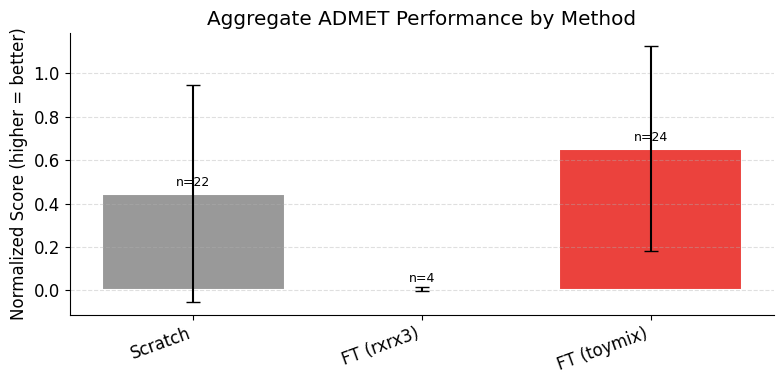

In [70]:
if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    admet_df = admet_df.copy()
    
    # Normalize within each task: map metric to [0, 1] where 1 = best
    scores = []
    for task, group in admet_df.groupby('task'):
        direction = TASK_METRICS.get(task, (None, 'higher'))[1]
        vals = group['primary_metric'].astype(float)
        if direction == 'lower':
            vals = -vals
        vmin, vmax = vals.min(), vals.max()
        if vmax == vmin:
            norm = pd.Series(0.5, index=group.index)
        else:
            norm = (vals - vmin) / (vmax - vmin)
        scores.append(norm)
    admet_df['normalized_score'] = pd.concat(scores).astype(float)
    
    agg = admet_df.groupby('method')['normalized_score'].agg(['mean', 'std', 'count'])
    # Order: Scratch first, then FT variants alphabetically
    order = ['Scratch'] + sorted([c for c in agg.index if c.startswith('FT')])
    order += [c for c in agg.index if c not in order]
    agg = agg.loc[[c for c in order if c in agg.index]]
    
    fig, ax = plt.subplots(figsize=(max(8, len(agg)*1.5), 4))
    palette = {'Scratch': '#999999'}
    ft_colors = ['#466eff', '#64B478', '#EB423D', '#FF883D', '#9B59B6']
    for i, m in enumerate(agg.index):
        if m not in palette:
            palette[m] = ft_colors[i % len(ft_colors)]
    colors = [palette.get(m, '#466eff') for m in agg.index]
    
    bars = ax.bar(range(len(agg)), agg['mean'], yerr=agg['std'],
                  color=colors, capsize=5, edgecolor='white', linewidth=1.5)
    ax.set_xticks(range(len(agg)))
    ax.set_xticklabels(agg.index, rotation=20, ha='right')
    ax.set_ylabel('Normalized Score (higher = better)')
    ax.set_title('Aggregate ADMET Performance by Method')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, axis='y', ls='--', alpha=0.4)
    
    for i, (bar, count) in enumerate(zip(bars, agg['count'])):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'n={int(count)}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
else:
    print("No ADMET results to aggregate.")

## 6. Per-task detail table

Full results table with all metrics for export.

In [71]:
if len(admet_df) > 0:
    summary = admet_df[['task', 'category', 'method', 'metric_name', 'primary_metric']].copy()
    task_order_map = {t: i for i, t in enumerate(ADMET_TASK_ORDER)}
    summary['_order'] = summary['task'].map(task_order_map)
    summary = summary.sort_values(['_order', 'method']).drop(columns='_order').reset_index(drop=True)
    display(summary)
    
    export_path = Path('../results/summary_table.csv')
    summary.to_csv(export_path, index=False)
    print(f"\nExported summary to {export_path}")

,task,category,method,metric_name,primary_metric
0,caco2_wang,Absorption,FT (rxrx3),mae,1.246150
1,caco2_wang,Absorption,FT (toymix),mae,0.537185
2,caco2_wang,Absorption,Scratch,mae,0.564809
3,hia_hou,Absorption,FT (rxrx3),auroc,0.498765
4,hia_hou,Absorption,FT (toymix),auroc,0.823251
5,hia_hou,Absorption,Scratch,auroc,0.500000
6,pgp_broccatelli,Absorption,FT (rxrx3),auroc,0.437283
7,pgp_broccatelli,Absorption,FT (toymix),auroc,0.770395
8,pgp_broccatelli,Absorption,Scratch,auroc,0.821381
9,bioavailability_ma,Absorption,FT (rxrx3),auroc,0.503658



Exported summary to ../results/summary_table.csv
